In [11]:
%load_ext autoreload
%autoreload 2

import cupy as cp
import math
from utils.data_loader import ImagenetteDataLoader
from model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [12]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(96, 96)
)

len(train_loader), train_loader.get_image_shape()

(9469, (3, 96, 96))

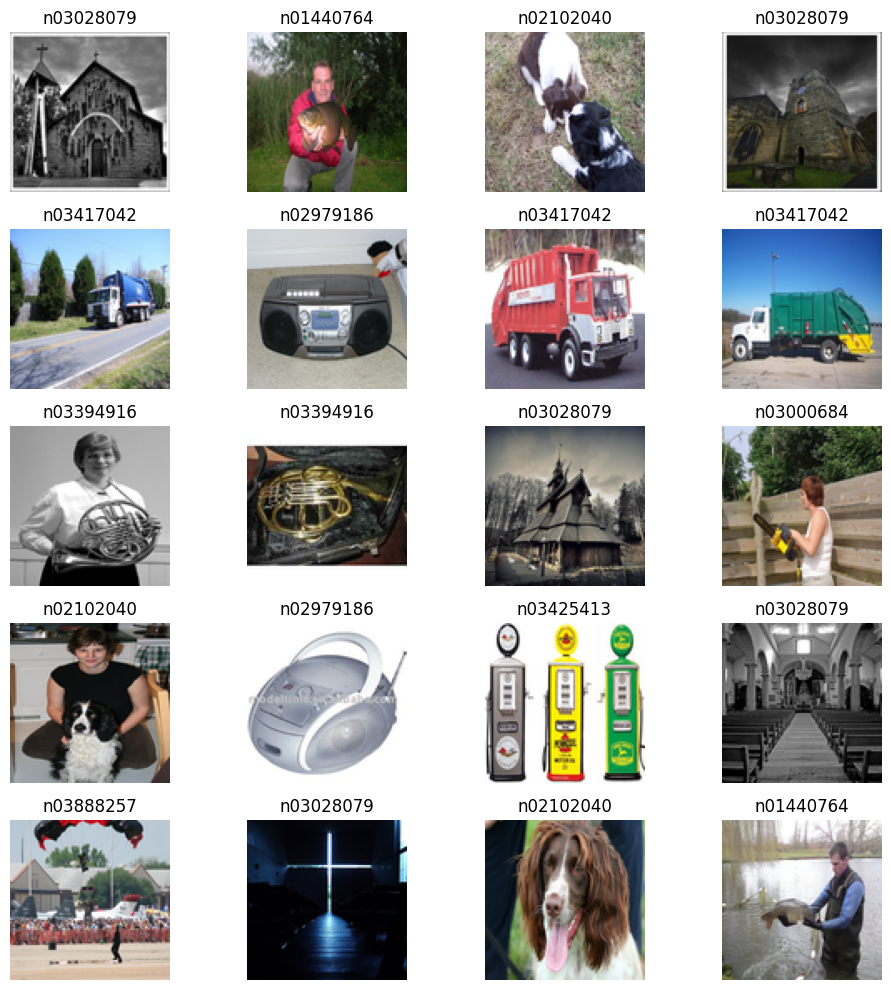

In [13]:
random_indices = cp.random.randint(0, len(train_loader), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [14]:
test_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="val",
    target_size=(96, 96)
)

len(test_loader), test_loader.get_image_shape()

(3925, (3, 96, 96))

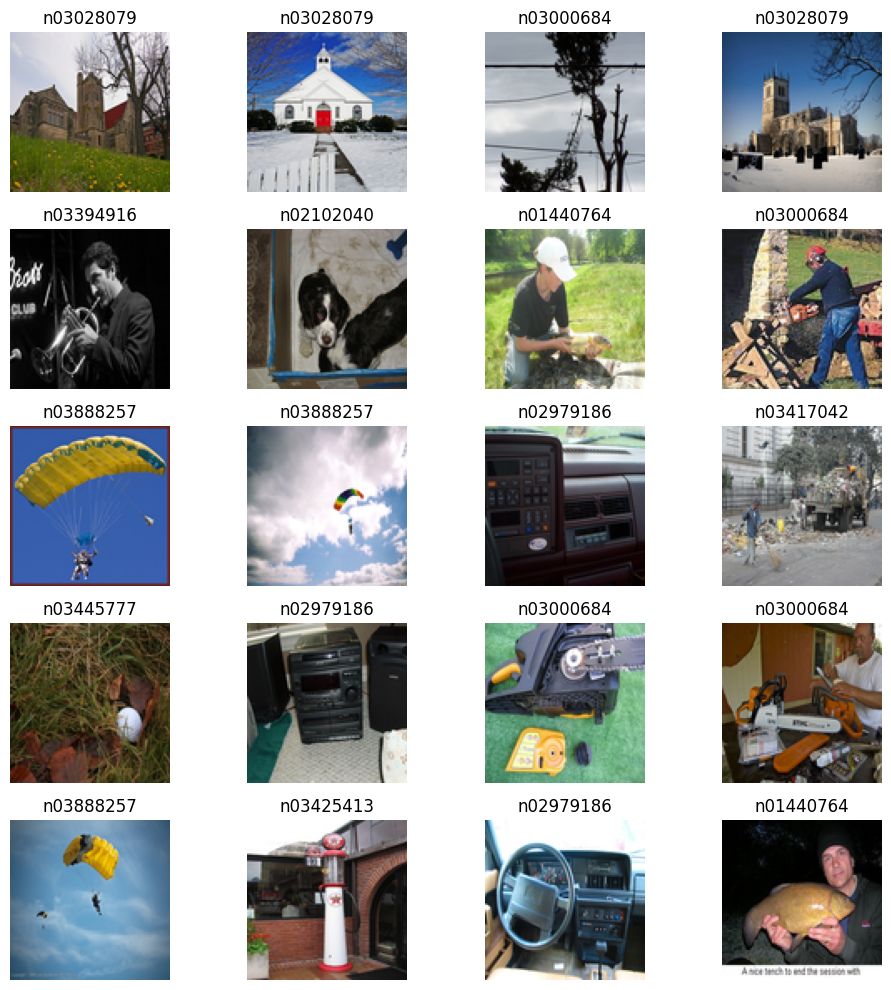

In [15]:
random_indices = cp.random.randint(0, len(test_loader), size=20)
test_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [ ]:
layer_definitions = [
    {"type": "ReLUConv", "num_filters": 16, "num_channels": 3, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 32, "num_channels": 16, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 64, "num_channels": 32, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 64, "num_channels": 64, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "Flatten"},
    {"type": "ReLU", "input_size": 1024, "num_neurons": 256},
    {"type": "ReLU", "input_size": 256, "num_neurons": 64},
    {"type": "Softmax", "input_size": 64, "num_neurons": 10},
]

network = Network(layer_definitions=layer_definitions)

In [17]:
network.describe()

Network Architecture

Layer 1: ConvLayer
  Filters Shape: (16, 3, 3, 3) | Biases Shape: (16,)
  Parameters: 448

Layer 2: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 3: ConvLayer
  Filters Shape: (32, 16, 3, 3) | Biases Shape: (32,)
  Parameters: 4,640

Layer 4: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 5: ConvLayer
  Filters Shape: (64, 32, 3, 3) | Biases Shape: (64,)
  Parameters: 18,496

Layer 6: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 7: ConvLayer
  Filters Shape: (64, 64, 3, 3) | Biases Shape: (64,)
  Parameters: 36,928

Layer 8: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 9: FlattenLayer
  Parameters: 0

Layer 10: ReluLayer
  Weights Shape: (1024, 256) | Biases Shape: (256,)
  Parameters: 262,400

Layer 11: ReluLayer
  Weights Shape: (256, 64) | Biases Shape: (64,)
  Parameters: 16,448

Layer 12: SoftmaxLayer
  Weights Shape: (64, 10) | Biases Shape: (10,)
  Parameters: 650

Total Parameters: 340,010


In [18]:
def evaluate_model(model, data_loader, batch_size, split_name="Validation"):
    total_loss = 0.0
    correct_predictions = 0
    num_samples = 0
    num_batches = (len(data_loader) + batch_size - 1) // batch_size

    for x_batch, y_batch in data_loader.iter_batches(
        batch_size=batch_size,
        normalize=True,
        one_hot=True,
        shuffle=False
    ):
        outputs = model.forward(input=x_batch)
        y_pred = outputs[-1]

        total_loss += model.cce_loss(y_pred=y_pred, y_true=y_batch).item()

        predicted_labels = cp.argmax(y_pred, axis=1)
        true_labels = cp.argmax(y_batch, axis=1)

        correct_predictions += cp.sum(predicted_labels == true_labels).item()
        num_samples += x_batch.shape[0]

    avg_loss = total_loss / num_batches
    accuracy = correct_predictions / num_samples
    print(f"{split_name} Loss: {avg_loss:.6f} | Accuracy: {accuracy:.4f}")

    return avg_loss, accuracy

In [19]:
def train_model(model, train_loader, test_loader, batch_size=16, epochs=10, base_learning_rate=0.003, min_learning_rate=0.0001):
    train_num_batches = (len(train_loader) + batch_size - 1) // batch_size
    total_steps = epochs * train_num_batches

    global_step = 0

    for epoch in range(epochs):
        total_loss = 0.0

        for batch_idx, (x_batch, y_batch) in enumerate(
            train_loader.iter_batches(
                batch_size=batch_size, 
                normalize=True, 
                one_hot=True, 
                shuffle=True, 
                aug_chance=0.5, 
                flip_chance=0.5
            ), start=1
        ):
            learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

            outputs = model.forward(input=x_batch)
            y_pred = outputs[-1]

            error = y_pred - y_batch
            loss = model.cce_loss(y_pred=y_pred, y_true=y_batch).item()
            total_loss += loss

            model.backward(output_error=error, batch_size=x_batch.shape[0])
            model.update_parameters(learning_rate=learning_rate)

            global_step += 1

        train_loss = total_loss / train_num_batches

        print(f"Epoch {epoch + 1}/{epochs} completed. Train Loss: {train_loss:.6f}")
        evaluate_model(
            model=model, 
            data_loader=test_loader, 
            batch_size=batch_size, 
            split_name="Validation"
        )

In [20]:
batch_size = 16
epochs = 30
base_learning_rate = 0.003
min_learning_rate = 0.0001

train_model(
    model=network,
    train_loader=train_loader,
    test_loader=test_loader,
    batch_size=batch_size,
    epochs=epochs,
    base_learning_rate=base_learning_rate,
    min_learning_rate=min_learning_rate
)

Epoch 1/30 completed. Train Loss: 2.124981
Validation Loss: 1.836615 | Accuracy: 0.3901
Epoch 2/30 completed. Train Loss: 1.835892
Validation Loss: 1.640344 | Accuracy: 0.4474
Epoch 3/30 completed. Train Loss: 1.701123
Validation Loss: 1.535717 | Accuracy: 0.4925
Epoch 4/30 completed. Train Loss: 1.608358
Validation Loss: 1.434465 | Accuracy: 0.5287
Epoch 5/30 completed. Train Loss: 1.557202
Validation Loss: 1.371848 | Accuracy: 0.5480
Epoch 6/30 completed. Train Loss: 1.491282
Validation Loss: 1.378801 | Accuracy: 0.5488
Epoch 7/30 completed. Train Loss: 1.449577
Validation Loss: 1.407958 | Accuracy: 0.5304
Epoch 8/30 completed. Train Loss: 1.411186
Validation Loss: 1.358559 | Accuracy: 0.5562
Epoch 9/30 completed. Train Loss: 1.365352
Validation Loss: 1.209149 | Accuracy: 0.6104
Epoch 10/30 completed. Train Loss: 1.340011
Validation Loss: 1.239710 | Accuracy: 0.5992
Epoch 11/30 completed. Train Loss: 1.304295
Validation Loss: 1.190982 | Accuracy: 0.6132
Epoch 12/30 completed. Train L

In [21]:
evaluate_model(
    model=network, 
    data_loader=train_loader, 
    batch_size=batch_size, 
    split_name="Train"
)

Train Loss: 0.705823 | Accuracy: 0.7850


(0.7058231111610919, 0.7849825747174992)

In [22]:
evaluate_model(
    model=network, 
    data_loader=test_loader, 
    batch_size=batch_size, 
    split_name="Test"
)

Test Loss: 1.049004 | Accuracy: 0.6657


(1.0490041948096402, 0.6657324840764332)